<h1><center>Stock Analysis</center></h1>

Import necessary libraries

In [68]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from alpha_vantage.timeseries import TimeSeries
from alpha_vantage.fundamentaldata import FundamentalData
from alpha_vantage.techindicators import TechIndicators
from alpha_vantage.econindicators import EconIndicators
from dotenv import load_dotenv
import os
import datetime


Import API and retrieve data

In [69]:
load_dotenv()

True

In [70]:
# Imports data
ts = TimeSeries('api_key', output_format='pandas')

stock, meta = ts.get_daily(symbol='QBTS', outputsize='full')

stock.head()

,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2025-10-30,32.9100,36.79,32.45,36.11,44418015.0
2025-10-29,32.4750,34.65,32.00,34.26,47219167.0
2025-10-28,35.2954,36.57,31.85,32.00,64548472.0
2025-10-27,33.9900,37.28,33.23,35.04,65054302.0
2025-10-24,33.1950,35.19,32.30,32.65,67660999.0


In [71]:
# View colmns
stock.columns

Index(['1. open', '2. high', '3. low', '4. close', '5. volume'], dtype='object')

In [72]:
# Rename columns
stock.rename(columns={'1. open': 'open', '2. high': 'high', '3. low': 'low', 
'4. close': 'close', '5. volume': 'volume'}, inplace = True)

In [73]:
# view first 5 rows to ensure column names changed.
stock.head()

,open,high,low,close,volume
date,,,,,
2025-10-30,32.9100,36.79,32.45,36.11,44418015.0
2025-10-29,32.4750,34.65,32.00,34.26,47219167.0
2025-10-28,35.2954,36.57,31.85,32.00,64548472.0
2025-10-27,33.9900,37.28,33.23,35.04,65054302.0
2025-10-24,33.1950,35.19,32.30,32.65,67660999.0


In [74]:
stock.tail()

,open,high,low,close,volume
date,,,,,
2022-08-12,11.36,11.5999,10.23,10.86,234128.0
2022-08-11,12.10,12.6999,11.35,11.86,282018.0
2022-08-10,11.71,13.2300,10.50,12.11,827034.0
2022-08-09,10.43,12.5000,7.50,12.40,940281.0
2022-08-08,8.98,13.1175,8.75,10.00,1461459.0


In [75]:
stock.shape

(812, 5)

In [76]:
ta = TechIndicators('api_key', output_format = 'pandas')

In [77]:
fd = FundamentalData('api_key' , output_format = 'pandas')

In [78]:
qbts, meta = ta.get_sma(symbol='QBTS')

In [79]:
qbts.shape

(793, 1)

In [80]:
qbts_div = fd.get_dividends('QBTS')

In [81]:
qbts_div 


(Empty DataFrame
 Columns: []
 Index: [],
 'QBTS')

In [82]:
qbts_split = fd.get_splits('QBTS')

In [83]:
qbts_split

(Empty DataFrame
 Columns: []
 Index: [],
 'QBTS')

<h1><center>EDA</center><h1>

In [84]:
stock.dtypes

open      float64
high      float64
low       float64
close     float64
volume    float64
dtype: object

In [85]:
stock['pct_ch_clo'] = stock['close'].pct_change() * 100

In [86]:
stock['pct_ch_clo'] = stock['pct_ch_clo'].round(2)

In [87]:
stock.head()

,open,high,low,close,volume,pct_ch_clo
date,,,,,,
2025-10-30,32.9100,36.79,32.45,36.11,44418015.0,NaN
2025-10-29,32.4750,34.65,32.00,34.26,47219167.0,-5.12
2025-10-28,35.2954,36.57,31.85,32.00,64548472.0,-6.60
2025-10-27,33.9900,37.28,33.23,35.04,65054302.0,9.50
2025-10-24,33.1950,35.19,32.30,32.65,67660999.0,-6.82


In [88]:
stock.tail()

,open,high,low,close,volume,pct_ch_clo
date,,,,,,
2022-08-12,11.36,11.5999,10.23,10.86,234128.0,1.50
2022-08-11,12.10,12.6999,11.35,11.86,282018.0,9.21
2022-08-10,11.71,13.2300,10.50,12.11,827034.0,2.11
2022-08-09,10.43,12.5000,7.50,12.40,940281.0,2.39
2022-08-08,8.98,13.1175,8.75,10.00,1461459.0,-19.35


In [89]:
stock.shape

(812, 6)

In [90]:
# Function to calculate Sharpe Ratio.
def calculate_sharp_ratio(ret, ann_rfr, periods):
    daily_rfr = ann_rfr/periods
    excess_ret = ret-daily_rfr
    mean_ex_ret = excess_ret.mean()
    std_ex_ret = excess_ret.std()

    if std_ex_ret == 0:
        return np.nan

    sharp_ratio = (mean_ex_ret/std_ex_ret) * np.sqrt(periods)

    return sharp_ratio

In [94]:
# call function to calculate Sharpe Ratio.
ann_rfr = 0.0377
periods = 252
ret = stock['pct_ch_clo']
sharpe = calculate_sharp_ratio(ret, ann_rfr, periods).round(2)
print(f"The Sharpe ratio for QBTS is:\n{sharpe}")

The Sharpe ratio for QBTS is:
0.45


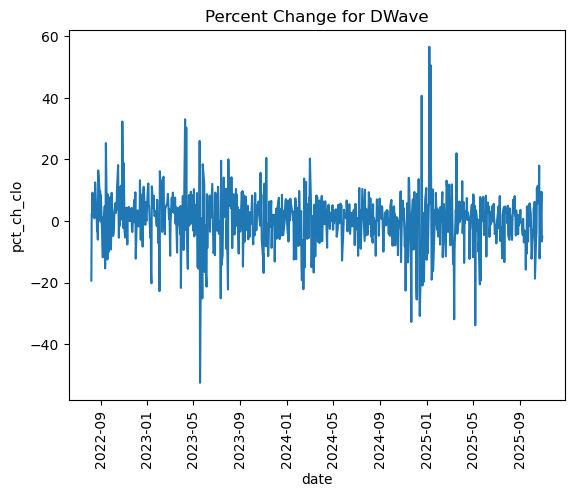

In [97]:
sns.lineplot(stock, x = 'date', y = 'pct_ch_clo')
plt.title('Percent Change for DWave')
plt.xticks(rotation=90)
plt.show()

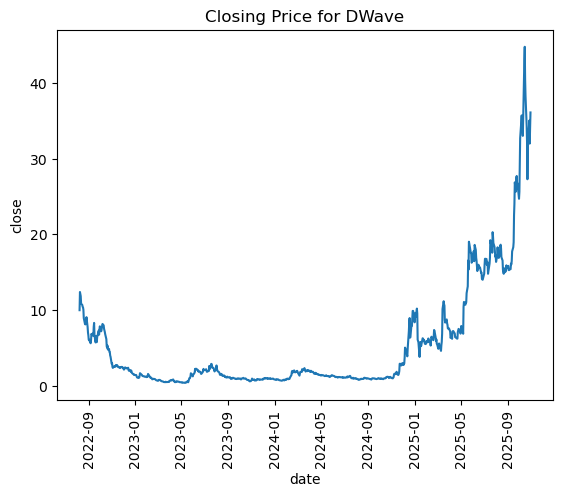

In [99]:
sns.lineplot(stock, x = 'date', y = 'close')
plt.title('Closing Price for DWave')
plt.xticks(rotation= 90)
plt.show()